In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model32_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model32_0)
describe(model32_0)

MACs: 4.44 MMac, Params: 24.57 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model32_0.pt
Starting
Epoch 1/60: Train loss = 1.2108, Train accuracy = 0.5774, Test loss = 1.2218, Test accuracy = 0.5854
Epoch 2/60: Train loss = 0.9420, Train accuracy = 0.6726, Test loss = 0.9551, Test accuracy = 0.6713
Epoch 3/60: Train loss = 0.9037, Train accuracy = 0.6882, Test loss = 0.8961, Test accuracy = 0.6997
Epoch 4/60: Train loss = 0.7377, Train accuracy = 0.7424, Test loss = 0.7344, Test accuracy = 0.7429
Epoch 5/60: Train loss = 0.6672, Train accuracy = 0.7656, Test loss = 0.6774, Test accuracy = 0.7687
Epoch 6/60: Train loss = 0.6916, Train accuracy = 0.7579, Test loss = 0.6645, Test accuracy = 0.7671
Epoch 7/60: Train loss = 0.6072, Train accuracy = 0.7862, Test loss = 0.6113, Test accuracy = 0.7874
Epoch 8/60: Train loss = 0.6105, Train accuracy = 0.7898, Test loss = 0.6247, Test accuracy = 0.7876
Epoch 9/60: Train loss = 0.6778, Train accuracy = 0.7690, Test loss = 0.6948, Test accuracy = 0.7690
Epoch 10/60: Train loss = 0.645

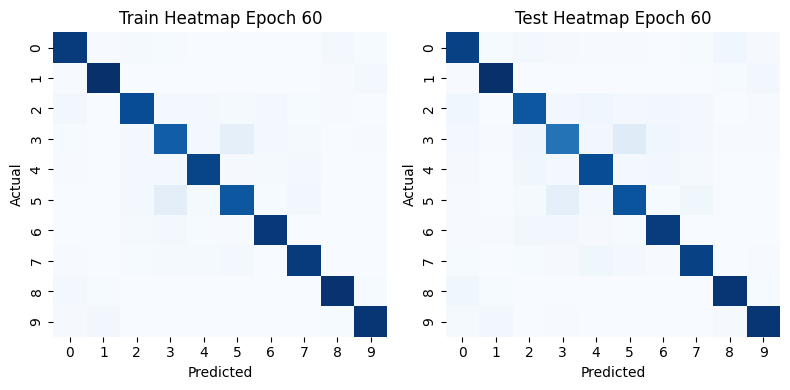

<Figure size 1200x600 with 0 Axes>

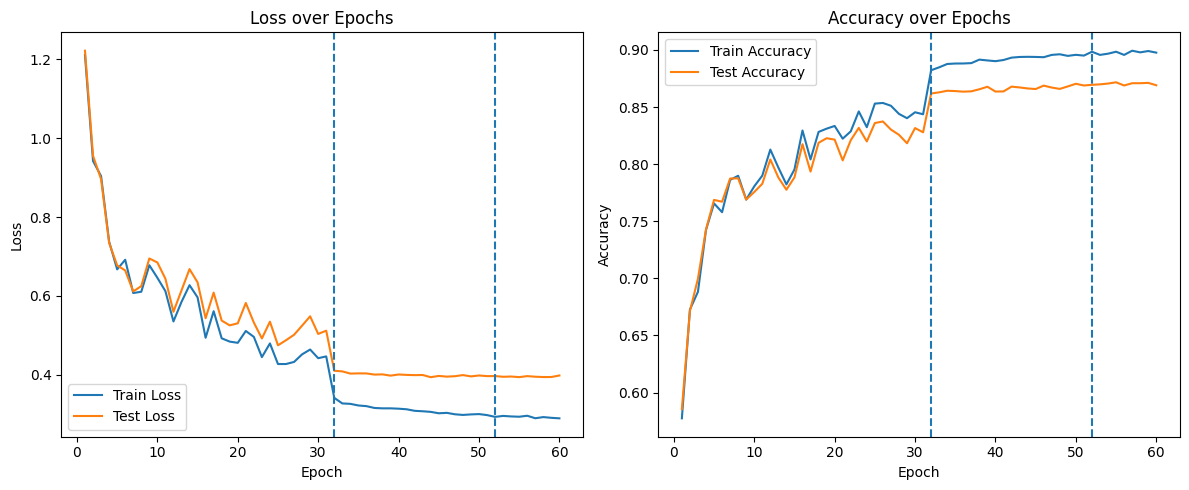

In [6]:
trainf32(model32_0,"model_weights/model32_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model32_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model32_1)
describe(model32_1)

MACs: 4.44 MMac, Params: 24.57 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model32_1.pt
Starting
Epoch 1/60: Train loss = 1.0218, Train accuracy = 0.6410, Test loss = 0.9968, Test accuracy = 0.6492
Epoch 2/60: Train loss = 0.8262, Train accuracy = 0.7094, Test loss = 0.8555, Test accuracy = 0.7049
Epoch 3/60: Train loss = 0.7782, Train accuracy = 0.7301, Test loss = 0.7677, Test accuracy = 0.7381
Epoch 4/60: Train loss = 0.7087, Train accuracy = 0.7535, Test loss = 0.7169, Test accuracy = 0.7601
Epoch 5/60: Train loss = 0.7627, Train accuracy = 0.7384, Test loss = 0.7717, Test accuracy = 0.7405
Epoch 6/60: Train loss = 0.6956, Train accuracy = 0.7623, Test loss = 0.6901, Test accuracy = 0.7712
Epoch 7/60: Train loss = 0.5983, Train accuracy = 0.7938, Test loss = 0.6230, Test accuracy = 0.7910
Epoch 8/60: Train loss = 0.5912, Train accuracy = 0.7976, Test loss = 0.6110, Test accuracy = 0.7928
Epoch 9/60: Train loss = 0.5496, Train accuracy = 0.8089, Test loss = 0.5672, Test accuracy = 0.8064
Epoch 10/60: Train loss = 0.539

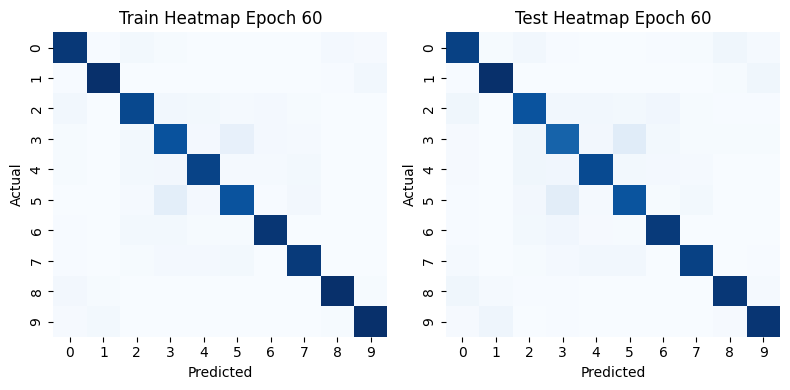

<Figure size 1200x600 with 0 Axes>

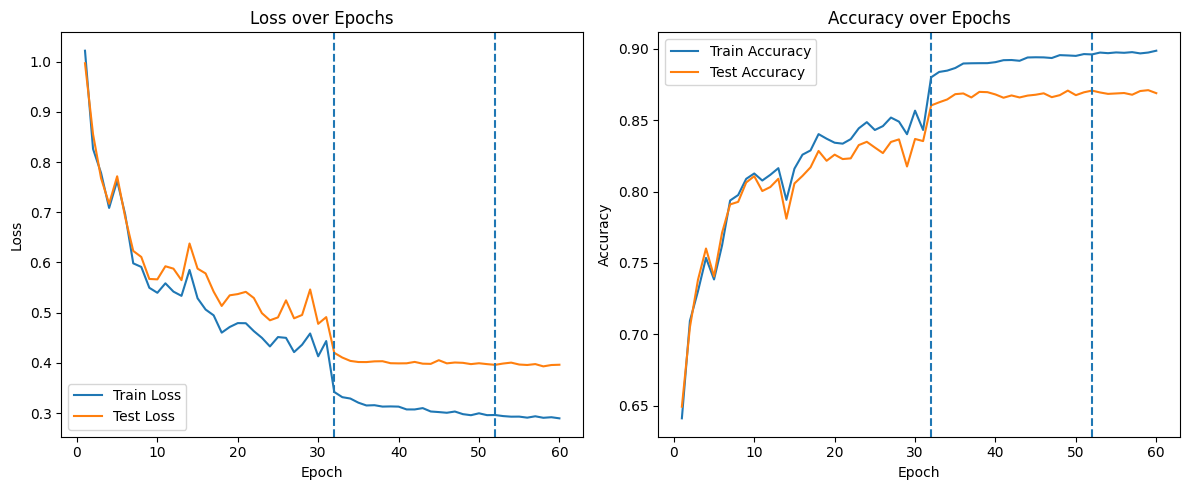

In [8]:
trainf32(model32_1,"model_weights/model32_1.pt",criterion,train_dataset,val_dataset, batch_size=64)